In [ ]:
!pip install -q timm

In [ ]:
'''perception-gap: do frozen encoders trained on photos separate meaningful satellite
changes from cosmetic ones?  SR = meaningful / (meaningful + cosmetic) shift, 0.5 = chance.

Shifts are cosine distances taken after subtracting the dataset mean. A dominant shared
direction compresses every shift by 1/(rho^2+1), which buries small signals at the floor
and made MAE and Pixtral look dead under a raw readout. Centering is step one of
all-but-the-top (arxiv/1702.01417; see also arxiv/2109.04404 on rogue dimensions).

EuroSAT arxiv/1709.00029.  Encoders: ViT 2010.11929, ResNet 1512.03385,
EfficientNet 1905.11946, ConvNeXt 2201.03545, MAE 2111.06377, DINO 2104.14294,
DINOv2 2304.07193, I-JEPA 2301.08243, Pixtral 2410.07073.
'''
import gc, os
import numpy as np, pandas as pd, torch
from torchvision import datasets, transforms

SEED, N_TILES, N_BOOT = 42, 300, 2000
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(SEED); np.random.seed(SEED)

tf = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
ds = datasets.EuroSAT("data", download=True, transform=tf)
tiles = [ds[i][0] for i in np.random.choice(len(ds), N_TILES, replace=False)]


def occlude_center(img, frac=0.4):
    out = img.clone()
    h, w = img.shape[1:]
    a, b = int(h * (1 - frac) / 2), int(w * (1 - frac) / 2)
    out[:, a:h - a, b:w - b] = img.mean((1, 2), keepdim=True)  # channel mean, not black:
    return out                                                 # 0 is off-distribution here

def scramble_patches(img, grid=4):
    h, w = img.shape[1:]
    ph, pw = h // grid, w // grid
    patches = [img[:, i * ph:(i + 1) * ph, j * pw:(j + 1) * pw]
               for i in range(grid) for j in range(grid)]
    out = torch.empty_like(img)
    for k, src in enumerate(np.random.permutation(len(patches))):
        i, j = divmod(k, grid)
        out[:, i * ph:(i + 1) * ph, j * pw:(j + 1) * pw] = patches[src]
    return out

def rotate_90(img):
    return torch.rot90(img, 1, (1, 2))

def flip_vertical(img):
    return torch.flip(img, (1,))

OCC_L2 = (tiles[0] - occlude_center(tiles[0])).norm().item()

def matched_noise(img):
    n = torch.randn_like(img)
    return (img + n * (OCC_L2 / n.norm())).clamp(-3, 3)  # same l2 as the occlusion

PERTURBATIONS = {
    "occlude_center":   ("meaningful", occlude_center),   # content removed
    "scramble_patches": ("meaningful", scramble_patches), # layout destroyed
    "rotate_90":        ("cosmetic", rotate_90),          # overhead tiles have no up
    "flip_vertical":    ("cosmetic", flip_vertical),
    "matched_noise":    ("cosmetic", matched_noise),
}

torch.manual_seed(SEED); np.random.seed(SEED)
PERTURBED = {k: [fn(t) for t in tiles] for k, (_, fn) in PERTURBATIONS.items()}


def features(featurize):
    base = np.stack([featurize(t) for t in tiles])
    return base, {k: np.stack([featurize(p) for p in imgs]) for k, imgs in PERTURBED.items()}

def cosine_shifts(base, pert, center=True):
    mu = base.mean(0, keepdims=True) if center else 0.0
    b = base - mu
    bn = np.linalg.norm(b, axis=1)
    return {k: 1.0 - (b * (p - mu)).sum(1) / (bn * np.linalg.norm(p - mu, axis=1) + 1e-12)
            for k, p in pert.items()}

def sr(shifts, idx=None):
    def g(kind):
        return float(np.mean([(s if idx is None else s[idx]).mean()
                              for k, s in shifts.items() if PERTURBATIONS[k][0] == kind]))
    sig, cos = g("meaningful"), g("cosmetic")
    return sig, cos, sig / (sig + cos)

def bootstrap_ci(shifts, n=N_BOOT, seed=0):
    rng = np.random.default_rng(seed)          # own stream, so the CI is reproducible
    N = len(next(iter(shifts.values())))
    return np.percentile([sr(shifts, rng.integers(0, N, N))[2] for _ in range(n)], [2.5, 97.5])


# each encoder is read at its own standard global summary vector, then centered
def dinov2(size):
    m = torch.hub.load("facebookresearch/dinov2", f"dinov2_vit{size}14", pretrained=True)
    m = m.eval().to(DEVICE)
    def f(img):
        with torch.no_grad():
            h = m.forward_features(img[None].to(DEVICE))["x_norm_patchtokens"]
        return h[0].mean(0).float().cpu().numpy()
    return f

def dino1():
    m = torch.hub.load("facebookresearch/dino:main", "dino_vitb16", pretrained=True)
    m = m.eval().to(DEVICE)
    def f(img):
        with torch.no_grad():
            return m(img[None].to(DEVICE))[0].float().cpu().numpy()
    return f

def torchvision_vit():
    from torchvision.models import vit_b_32, ViT_B_32_Weights
    m = vit_b_32(weights=ViT_B_32_Weights.IMAGENET1K_V1).eval().to(DEVICE)
    m.heads = torch.nn.Identity()
    def f(img):
        with torch.no_grad():
            return m(img[None].to(DEVICE))[0].float().cpu().numpy()
    return f

def resnet50():
    from torchvision.models import resnet50 as build, ResNet50_Weights
    m = build(weights=ResNet50_Weights.IMAGENET1K_V2).eval().to(DEVICE)
    m.fc = torch.nn.Identity()
    def f(img):
        with torch.no_grad():
            return m(img[None].to(DEVICE))[0].float().cpu().numpy()
    return f

def timm_model(name):
    import timm
    m = timm.create_model(name, pretrained=True, num_classes=0).eval().to(DEVICE)
    def f(img):
        with torch.no_grad():
            return m(img[None].to(DEVICE))[0].float().cpu().numpy()
    return f

def ijepa(repo):
    from transformers import AutoModel
    m = AutoModel.from_pretrained(repo, dtype=torch.float16).eval().to(DEVICE)
    def f(img):
        with torch.no_grad():
            h = m(pixel_values=img[None].to(DEVICE).half()).last_hidden_state
        return h[0].mean(0).float().cpu().numpy()
    return f

def pixtral():
    # vision tower lifted out of the 12B checkpoint, downloading only the shards it lives in.
    # the assert matters: a silent partial load leaves random weights and still returns numbers
    import json, safetensors.torch
    from huggingface_hub import hf_hub_download
    from transformers import AutoConfig, PixtralVisionModel

    repo = "mistral-community/pixtral-12b"
    m = PixtralVisionModel(AutoConfig.from_pretrained(repo).vision_config)
    wmap = json.load(open(hf_hub_download(repo, "model.safetensors.index.json")))["weight_map"]
    prefix = next(k for k in wmap if k.endswith("patch_conv.weight"))[:-len("patch_conv.weight")]
    state = {}
    for shard in sorted({s for k, s in wmap.items() if k.startswith(prefix)}):
        sd = safetensors.torch.load_file(hf_hub_download(repo, shard))
        state.update({k[len(prefix):]: v for k, v in sd.items() if k.startswith(prefix)})
    missing, _ = m.load_state_dict(state, strict=False)
    assert not missing, f"pixtral vision weights missing: {missing[:5]}"
    m = m.eval().to(DEVICE).half()

    def f(img):
        x = img[None].to(DEVICE).half()
        with torch.no_grad():
            out = m(pixel_values=x, image_sizes=torch.tensor([x.shape[-2:]], device=DEVICE))
        h = getattr(out, "last_hidden_state", None)
        return (out[0] if h is None else h)[0].mean(0).float().cpu().numpy()
    return f


MODELS = [
    ("DINOv2 ViT-S/14",       "self-distillation", "LVD-142M",   lambda: dinov2("s")),
    ("DINOv2 ViT-B/14",       "self-distillation", "LVD-142M",   lambda: dinov2("b")),
    ("DINOv1 ViT-B/16",       "self-distillation", "IN-1K",      dino1),
    ("ViT-B/32",              "supervised",        "IN-1K",      torchvision_vit),
    ("ResNet-50",             "supervised",        "IN-1K",      resnet50),
    ("ConvNeXt-Tiny",         "supervised",        "IN-22K",     lambda: timm_model("convnext_tiny.fb_in22k")),
    ("EfficientNet-B0",       "supervised",        "IN-1K",      lambda: timm_model("efficientnet_b0.ra_in1k")),
    ("MAE ViT-B/16",          "reconstruction",    "IN-1K",      lambda: timm_model("vit_base_patch16_224.mae")),
    ("I-JEPA ViT-H/14",       "joint-embedding",   "IN-1K",      lambda: ijepa("facebook/ijepa_vith14_1k")),
    ("I-JEPA ViT-H/14 (22k)", "joint-embedding",   "IN-22K",     lambda: ijepa("facebook/ijepa_vith14_22k")),
    ("Pixtral-ViT",           "language",          "image-text", pixtral),
]

rows, detail = [], []
for name, objective, data, load in MODELS:
    f = None
    try:
        f = load()
        base, pert = features(f)
    except Exception as e:
        print(f"{name:<22} failed: {type(e).__name__}: {e}")
        continue
    finally:
        f = None
        gc.collect(); torch.cuda.empty_cache()

    shifts = cosine_shifts(base, pert)
    sig, cos, ratio = sr(shifts)
    lo, hi = bootstrap_ci(shifts)
    print(f"{name:<22} {ratio:.3f}  [{lo:.3f} {hi:.3f}]   signal {sig:.3f}  cosmetic {cos:.3f}")
    rows.append(dict(model=name, objective=objective, data=data, signal=sig,
                     cosmetic=cos, sr=ratio, ci_low=lo, ci_high=hi))
    detail += [dict(model=name, perturbation=k, kind=PERTURBATIONS[k][0],
                    mean_shift=float(v.mean())) for k, v in shifts.items()]

summary = pd.DataFrame(rows).sort_values("sr", ascending=False)
summary["inert"] = summary.signal < 0.02   # below this SR is noise over noise, don't read it
print()
print(summary.to_string(index=False))

os.makedirs("results", exist_ok=True)
summary.to_csv("results/sr_by_model.csv", index=False)
pd.DataFrame(detail).to_csv("results/shift_by_perturbation.csv", index=False)

100%|██████████| 94.3M/94.3M [00:01<00:00, 64.1MB/s]


Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip


/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vits14/dinov2_vits14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vits14_pretrain.pth


100%|██████████| 84.2M/84.2M [00:00<00:00, 203MB/s]


...

config.json:   0%|          | 0.00/997 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/57.9k [00:00<?, ?B/s]

model-00001-of-00006.safetensors: reconstructing file:   0%|          |  0.00B / 4.99GB            

model-00001-of-00006.safetensors: downloading bytes:           |  0.00B            

Pixtral-ViT            0.632  [0.619 0.645]   signal 0.357  cosmetic 0.208

                model         objective       data   signal  cosmetic       sr   ci_low  ci_high  inert
I-JEPA ViT-H/14 (22k)   joint-embedding     IN-22K 0.385586  0.129859 0.748065 0.738522 0.757787  False
         MAE ViT-B/16    reconstruction      IN-1K 0.092185  0.039073 0.702320 0.690290 0.714594  False
      DINOv1 ViT-B/16 self-distillation      IN-1K 0.294648  0.127025 0.698759 0.688436 0.709055  False
      I-JEPA ViT-H/14   joint-embedding      IN-1K 0.285481  0.139839 0.671215 0.658237 0.683193  False
             ViT-B/32        supervised      IN-1K 0.290323  0.144024 0.668413 0.658595 0.678173  False
      DINOv2 ViT-B/14 self-distillation   LVD-142M 0.228130  0.116098 0.662729 0.646886 0.678308  False
      EfficientNet-B0        supervised      IN-1K 0.264310  0.140903 0.652273 0.640355 0.663149  False
      DINOv2 ViT-S/14 self-distillation   LVD-142M 0.221534  0.127048 0.635530 0.620244 0.65

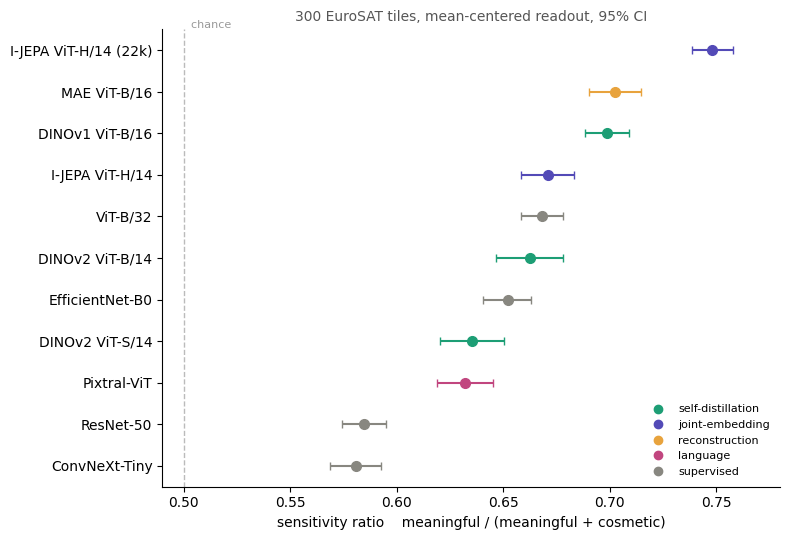

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

COLORS = {"self-distillation": "#1D9E75", "joint-embedding": "#534AB7",
          "reconstruction": "#E8A33D", "language": "#C1467F", "supervised": "#888780"}
df = summary.sort_values("sr")

fig, ax = plt.subplots(figsize=(8, 5.5))
for y, r in enumerate(df.itertuples()):
    c = COLORS[r.objective]
    ax.errorbar(r.sr, y, xerr=[[r.sr - r.ci_low], [r.ci_high - r.sr]], fmt="o", ms=7,
                color=c, ecolor=c, elinewidth=1.5, capsize=3,
                mfc="white" if r.inert else c, alpha=0.5 if r.inert else 1.0, zorder=3)
ax.axvline(0.5, ls="--", lw=1, color="#bbb", zorder=1)
ax.text(0.5, len(df) - 0.4, "  chance", color="#999", fontsize=8, va="center")
ax.set_yticks(range(len(df)), df.model)
ax.set_xlim(0.49, 0.78)
ax.set_xlabel("sensitivity ratio    meaningful / (meaningful + cosmetic)")
ax.set_title("300 EuroSAT tiles, mean-centered readout, 95% CI", fontsize=10, color="#555")
handles = [Line2D([], [], marker="o", ls="", color=c, label=k)
           for k, c in COLORS.items() if k in set(df.objective)]
if df.inert.any():
    handles.append(Line2D([], [], marker="o", ls="", color="#888780", mfc="white",
                          label="inert, SR not readable"))
ax.legend(handles=handles, fontsize=8, loc="lower right", frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
os.makedirs("figures", exist_ok=True)
plt.savefig("figures/sr_by_model.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
'''why the readout is centered. rho^2 = ||mu||^2 / E||v||^2 is how much of a model's
feature vector is a constant shared direction; the raw cosine shift is then the
centered one times 1/(rho^2+1). DINOv2 has almost no shared bias so centering does
nothing to it. MAE is buried under one and only reads at all once it is removed.
'''
print(f"{'':<18}{'rho^2':>8}{'signal raw':>12}{'centered':>10}"
      f"{'predicted':>11}{'observed':>10}{'SR raw':>9}{'SR cen':>8}")
for name, load in [("DINOv2 ViT-S/14", lambda: dinov2("s")),
                   ("MAE ViT-B/16", lambda: timm_model("vit_base_patch16_224.mae"))]:
    f = load()
    base, pert = features(f)
    f = None; gc.collect(); torch.cuda.empty_cache()
    rho2 = float(np.linalg.norm(base.mean(0)) ** 2 / (base - base.mean(0)).var(0).sum())
    raw, cen = sr(cosine_shifts(base, pert, center=False)), sr(cosine_shifts(base, pert))
    print(f"{name:<18}{rho2:8.1f}{raw[0]:12.4f}{cen[0]:10.4f}"
          f"{1/(rho2+1):11.4f}{raw[0]/cen[0]:10.4f}{raw[2]:9.3f}{cen[2]:8.3f}")

                     rho^2  signal raw  centered  predicted  observed   SR raw  SR cen


Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


DINOv2 ViT-S/14        0.8      0.1198    0.2215     0.5668    0.5407    0.628   0.636
MAE ViT-B/16           7.0      0.0041    0.0922     0.1256    0.0440    0.717   0.702


In [ ]:
'''MAE compresses about 3x harder than rho^2 alone predicts. If that excess is anisotropy,
it lives in a few high-variance directions the perturbations never move. all-but-the-top
(arxiv/1702.01417) strips the mean AND the leading principal directions; cell 3 stripped
only the mean. Sweep k. If the story holds, variance in the top k is large while
displacement in the top k stays near zero, and signal climbs then plateaus.
'''
def strip_top(base, pert, Vt, k):
    mu = base.mean(0, keepdims=True)
    b, p = base - mu, {n: v - mu for n, v in pert.items()}
    if k:
        V = Vt[:k]
        b = b - (b @ V.T) @ V
        p = {n: v - (v @ V.T) @ V for n, v in p.items()}
    return b, p

for name, load in [("DINOv2 ViT-S/14", lambda: dinov2("s")),
                   ("MAE ViT-B/16", lambda: timm_model("vit_base_patch16_224.mae"))]:
    f = load()
    base, pert = features(f)
    f = None; gc.collect(); torch.cuda.empty_cache()

    b0 = base - base.mean(0, keepdims=True)
    S, Vt = np.linalg.svd(b0, full_matrices=False)[1:]
    lam = S ** 2
    vfrac = np.cumsum(lam) / lam.sum()
    disp = np.concatenate([pert[n] - base for n in pert])
    disp_energy = (disp ** 2).sum()
    mu2 = float(np.linalg.norm(base.mean(0)) ** 2)
    raw_signal = sr(cosine_shifts(base, pert, center=False))[0]

    print(f"\n{name}   raw signal {raw_signal:.4f}")
    print(f"{'k':>3}{'var in top k':>14}{'displ in top k':>16}{'signal':>10}"
          f"{'SR':>8}{'observed':>10}{'predicted':>11}")
    for k in (0, 1, 2, 4, 8, 16, 32):
        b, p = strip_top(base, pert, Vt, k)
        sig, cos, ratio = sr(cosine_shifts(b, p, center=False))
        vf = float(vfrac[k - 1]) if k else 0.0
        df = float(((disp @ Vt[:k].T) ** 2).sum() / disp_energy) if k else 0.0
        rho2 = (len(base) * mu2 + lam[:k].sum()) / (lam.sum() - lam[:k].sum())  # mean+top k as bias
        print(f"{k:>3}{vf:14.3f}{df:16.3f}{sig:10.4f}{ratio:8.3f}"
              f"{raw_signal / sig:10.4f}{1 / (rho2 + 1):11.4f}")

Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main



DINOv2 ViT-S/14   raw signal 0.1198
  k  var in top k  displ in top k    signal      SR  observed  predicted
  0         0.000           0.000    0.2215   0.636    0.5407     0.5668
  1         0.217           0.052    0.2544   0.626    0.4708     0.4440
  2         0.316           0.100    0.2729   0.620    0.4389     0.3878
  4         0.455           0.154    0.3052   0.611    0.3925     0.3088
  8         0.564           0.215    0.3396   0.605    0.3527     0.2470
 16         0.679           0.306    0.3859   0.597    0.3104     0.1818
 32         0.794           0.430    0.4480   0.591    0.2674     0.1165

MAE ViT-B/16   raw signal 0.0041
  k  var in top k  displ in top k    signal      SR  observed  predicted
  0         0.000           0.000    0.0922   0.702    0.0440     0.1256
  1         0.816           0.059    0.2368   0.680    0.0171     0.0231
  2         0.931           0.072    0.3905   0.665    0.0104     0.0087
  4         0.970           0.141    0.5348   0.630  